# 电机控制带练：采样、积分饱和与停止距离

配套：[控制连续带练](../engineering/07_control.md#worked-lessons)。先用可手算的理想P环，再加入惯量、粘性阻力和限幅比较PI恢复。模型不含真实电机电流环、重力、间隙和电气保护，参数不能搬到真机。


In [1]:
from pathlib import Path
import sys, math, csv, json

# Locate the course even when the kernel starts in notebooks/.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "labs" / "course_lab.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the complete trainning_materials folder.")
sys.path.insert(0, str(ROOT / "labs"))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, HTML
import ipywidgets as widgets
from course_lab import fk, ik, encode_frame, decode_frame, feedback_fresh, sphere_gap, fit_line, mse
from algorithm_lab import jacobian, numerical_ik, astar, trapezoid, kalman_step, pid_demo
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})
print("Python:", sys.executable)
print("Course:", ROOT.name)


Python: D:\code_agent\trainning_materials\.venv\Scripts\python.exe
Course: trainning_materials


In [2]:
from workshop_lab import speed_pi, stopping_distance


## 1. 手算五步误差，再画出三种P环
理想速度接口下e_next=(1−Kp*dt)e。dt=0.01，Kp=10/150/250时，乘子分别0.9/−0.5/−1.5。先预测单调、交替衰减、交替放大，再执行。


Kp 10 first five: [1.0, 0.9, 0.81, 0.7290000000000001, 0.6561000000000001]
Kp 150 first five: [1.0, -0.5, 0.25, -0.125, 0.0625]
Kp 250 first five: [1.0, -1.5, 2.25, -3.375, 5.0625]


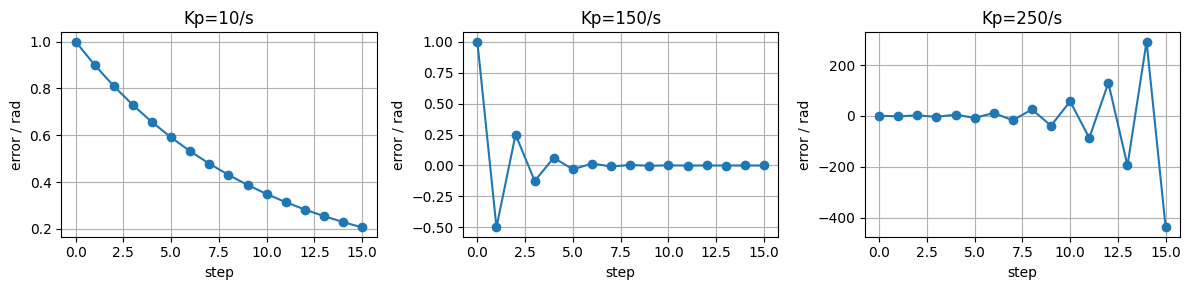

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, kp in zip(axes, (10, 150, 250)):
    e = 1.; errors = [e]
    for _ in range(15):
        e = (1-kp*.01)*e
        errors.append(e)
    print("Kp", kp, "first five:", errors[:5])
    ax.plot(errors, "o-"); ax.set(title=f"Kp={kp}/s", xlabel="step", ylabel="error / rad")
plt.tight_layout(); plt.show()


## 2. 在跑PI前先算目标是否能达到
J=0.2，b=0.3，力矩上限1N·m，目标4rad/s。稳态需要b*v=1.2N·m，超过限值；这次故意制造持续误差。3秒后目标改为0，用恢复过程比较积分处理。


In [4]:
print("required torque:", .3*4, "limit:", 1., "steady maximum speed:", 1/.3)
without_aw = speed_pi(antiwindup=False)
with_aw = speed_pi(antiwindup=True)
assert all(abs(r["torque_nm"]) <= 1 for r in with_aw + without_aw)
print("samples per run:", len(with_aw))


required torque: 1.2 limit: 1.0 steady maximum speed: 3.3333333333333335
samples per run: 1600


## 3. 同时看速度、积分和实际输出
如果只看最后一刻，可能看不到恢复期间的差别。找3秒目标改变前后：哪条曲线仍带着较大积分？哪条实际输出与未限幅要求不一致？


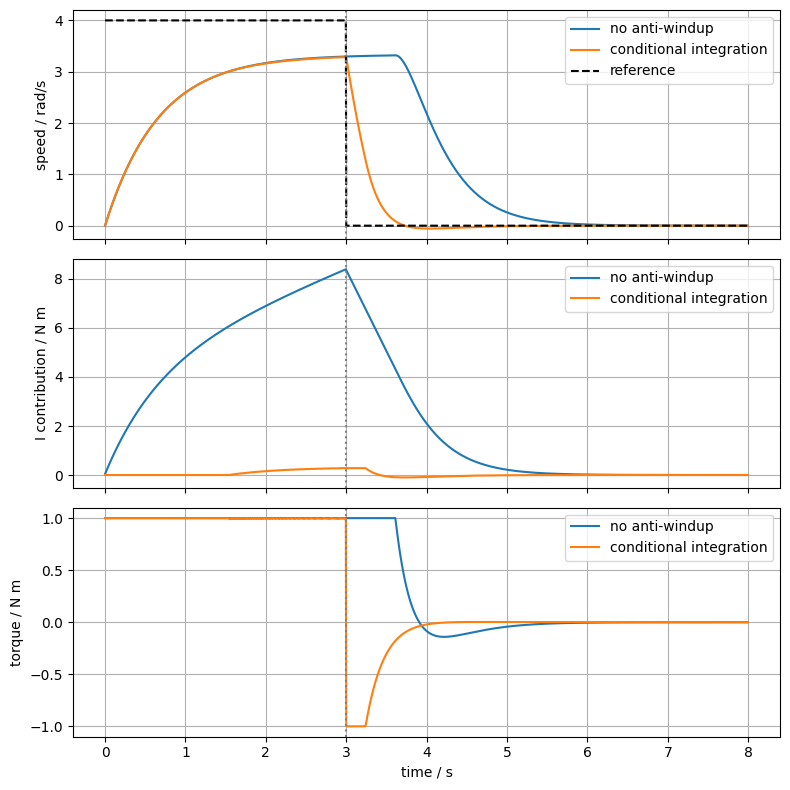

In [5]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
for label, rows in [("no anti-windup", without_aw), ("conditional integration", with_aw)]:
    times = [r["t_s"] for r in rows]
    for ax, key in zip(axes, ("velocity_rad_s", "integral_nm", "torque_nm")):
        ax.plot(times, [r[key] for r in rows], label=label)
axes[0].plot(times, [r["reference_rad_s"] for r in with_aw], "k--", label="reference")
for ax, ylabel in zip(axes, ("speed / rad/s", "I contribution / N m", "torque / N m")):
    ax.set_ylabel(ylabel); ax.axvline(3, color="gray", ls=":"); ax.legend()
axes[-1].set_xlabel("time / s"); plt.tight_layout(); plt.show()


## 4. 用指标描述结果
计算3秒后的速度绝对误差积分：每步|v−0|乘dt再相加。积分项峰值不是“越小越好”的独立目标，需与跟踪、输出限制和任务一起看。


In [6]:
metrics = {}
for label, rows in [("no_aw", without_aw), ("with_aw", with_aw)]:
    metrics[label] = {
        "release_error_integral_rad": sum(abs(r["velocity_rad_s"])*.005 for r in rows if r["t_s"] >= 3),
        "max_integral_nm": max(abs(r["integral_nm"]) for r in rows),
        "saturation_fraction": sum(r["saturated"] for r in rows)/len(rows),
    }
    print(label, metrics[label])
assert metrics["with_aw"]["release_error_integral_rad"] < metrics["no_aw"]["release_error_integral_rad"]


no_aw {'release_error_integral_rad': 4.197875834706051, 'max_integral_nm': 8.395901429871875, 'saturation_fraction': 0.451875}
with_aw {'release_error_integral_rad': 0.7835984496412298, 'max_integral_nm': 0.27975084890282587, 'saturation_fraction': 0.22125}


## 5. 改参数时固定其他条件
改力矩上限后，目标的可达性也变了。将limit设为2，再比较两条曲线；改J只改变本模型瞬态，不改变稳态u=b*v。滑块每次计算都从同一初态开始。


interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='inertia', max=0.5, min=0.1)…

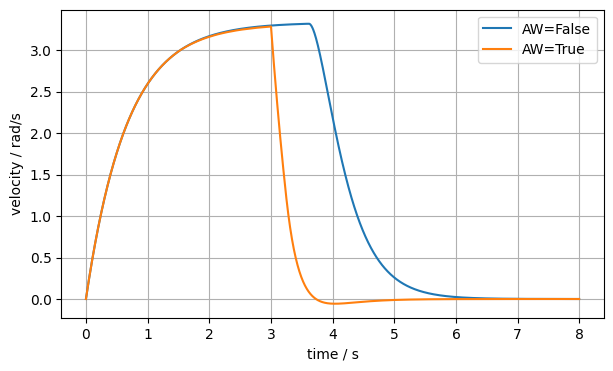

In [7]:
def compare_pi(inertia=.2, limit=1.):
    for aw in (False, True):
        rows = speed_pi(inertia=inertia, limit=limit, antiwindup=aw)
        plt.plot([r["t_s"] for r in rows], [r["velocity_rad_s"] for r in rows], label=f"AW={aw}")
    plt.xlabel("time / s"); plt.ylabel("velocity / rad/s"); plt.legend(); plt.show()
display(widgets.interactive(compare_pi,
    inertia=widgets.FloatSlider(value=.2, min=.1, max=.5, step=.1, continuous_update=False),
    limit=widgets.FloatSlider(value=1., min=.5, max=2., step=.5, continuous_update=False)))
compare_pi()


## 6. 停止距离进入时间预算
假设延迟期间匀速，随后恒定减速度1m/s²。公式v*L+v²/(2a)只适用于这个教学模型，不是设备的认证停止能力。先手算v=.5、L=.04得到.145m，再比较速度与延迟变化。


base: 0.145 double delay: 0.165 double speed: 0.54


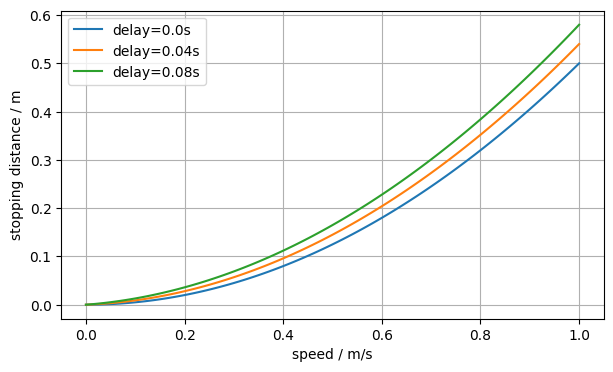

In [8]:
base = stopping_distance(.5, 1., .04)
print("base:", base, "double delay:", stopping_distance(.5, 1., .08),
      "double speed:", stopping_distance(1., 1., .04))
assert abs(base - .145) < 1e-12
speeds = np.linspace(0, 1., 101)
for delay in (0., .04, .08):
    plt.plot(speeds, [stopping_distance(float(v), 1., delay) for v in speeds], label=f"delay={delay}s")
plt.xlabel("speed / m/s"); plt.ylabel("stopping distance / m"); plt.legend(); plt.show()


## 7. 练习解析与交付
将理想P环dt改成0.03而Kp保持100，乘子为−2，会发散。PI目标不可达时增加Ki不能创造输出能力；它可能加重积分积累。停止延迟翻倍只使延迟距离翻倍，速度翻倍会使制动距离变四倍。

保存参数、三条曲线和恢复指标，解释一次修改为什么有效。实际电机另需模式、单位、负载、反馈时延、限制和停止验证。


In [9]:
out = ROOT / "outputs" / "workshop_control.json"
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps({"scope": "first-order offline speed model", "metrics": metrics}, indent=2) + "\n", encoding="utf-8")
print("Saved:", out)


Saved: D:\code_agent\trainning_materials\outputs\workshop_control.json
